
# Proyecto de modelo de análisis de datos en Python
# Alumno: Ángel Tomás Moreno Senén
# Curso de especialización programación con Python
# Curso escolar 2025/2026
# IES Severo Ochoa

**EL CUADERNO HA SIDO COMPARTIDO CON EL PROFESOR CON PRIVILEGIOS DE EDITOR (COMPROBADO)**

*Hoy es 21/05/2026... ahora sólo markdown, nada de fastidiar lo hecho que funciona.*

Tengo la costumbre de ir subiendo las cosas a GitHub y por eso no lo fui subiendo a Kaggle. La URL del Repositorio está abajo.

# https://github.com/atmsDAWDAMAlicante/CEPython2526/tree/main/Modulo_3_Analisis_de_datos/PROYECTO_KAGGLE

In [59]:
# 1 Proyecto de modelo de análisis de datos en Python
# Alumno: Ángel Tomás Moreno Senén
# Curso de especialización programación con Python
# Curso escolar 2025/2026
# IES Severo Ochoa

#### esto esta para pasar a limpio y poner mas texto y arreglarlo un poco!!!!!!!!!!!!!!!!!!!!!!!!!!!!! Y YO LO IBA SUBIENDO LOS COMMITS A GITHUB
# QUE TENGO LA COSTUMBRE DE SUBIR LAS COSAS A GITHUB Y NO ME DI CUENTA DE LO DE SUBIRLO A KAGGLE

# https://github.com/atmsDAWDAMAlicante/CEPython2526/tree/main/Modulo_3_Analisis_de_datos/PROYECTO_KAGGLE

In [60]:
# 2 El primer paso, importar pandas y numpy
import pandas as pd
import numpy as np


## Carga de datos

Se cargan los conjuntos de entrenamiento y test proporcionados por el profesor en la competición de Kaggle en formato CSV.

El conjunto de entrenamiento contiene la variable objetivo (**CONSUMO_EP_VALOR**).
El conjunto de test se utilizará para las predicciones finales.

In [61]:
# 3 Subir los archivos
train_df = pd.read_csv("train.csv")
test_df = pd.read_csv("test.csv")


## Inicio del EDA

Se realizan verificaciones iniciales sobre los conjuntos de entrenamiento y test para confirmar que los datos se han cargado correctamente y observar la estructura general de las variables.

In [62]:
# 4 Comprobar que se han subido Train
print ("¿Ha subido el Train?")
train_df.head()


¿Ha subido el Train?


,id,ANYO_CONSTRUCCION,CODIGO_POSTAL,USO_EDIFICIO,MUNICIPIO,PROVINCIA,TIPO_REGISTRO,FICHERO_ORIGEN,CONSUMO_EP_VALOR
0,23809,2018.0,3178.0,VIVIENDA/S UNIFAMILIAR,BENIJÓFAR,ALICANTE,NUEVO,NaN,47
1,34002,2007.0,3410.0,VIVIENDA INDIVIDUAL,BIAR,ALICANTE,EXISTE,certificacion-energetica-de-edificios-en-alica...,165
2,40936,1996.0,3010.0,NaN,ALICANTE/ALACANT,ALICANTE,EXISTE,certificacion-energetica-de-edificios-en-alica...,89
3,41393,1975.0,46115.0,VIVIENDA INDIVIDUAL,ALFARA DEL PATRIARCA,VALENCIA,EXISTE,certificacion-energetica-de-edificios-en-valen...,184
4,8708,2002.0,NaN,VIVIENDA INDIVIDUAL,ROJALES,ALICANTE,EXISTE,certificacion-energetica-de-edificios-en-alica...,296


In [63]:
# 5 Comprobar que se han subido Test
print("¿Ha subido el Test?")
test_df.head()

¿Ha subido el Test?


,id,ANYO_CONSTRUCCION,CODIGO_POSTAL,USO_EDIFICIO,MUNICIPIO,PROVINCIA,TIPO_REGISTRO,FICHERO_ORIGEN
0,33554,1988.0,46680,VIVIENDA/S UNIFAMILIAR,ALGEMESÍ,VALENCIA,EXISTE,CERTIFICACION-ENERGETICA-DE-EDIFICIOS-EN-VALEN...
1,9428,2001.0,3177,VIVIENDA/S UNIFAMILIAR,SAN FULGENCIO,ALICANTE,EXISTE,CERTIFICACION-ENERGETICA-DE-EDIFICIOS-EN-ALICA...
2,200,1950.0,46006,VIVIENDA/S UNIFAMILIAR,VALENCIA,VALENCIA,EXISTE,CERTIFICACION-ENERGETICA-DE-EDIFICIOS-EN-VALEN...
3,12448,1992.0,3780,VIVIENDA INDIVIDUAL,PEGO,ALICANTE,EXISTE,CERTIFICACION-ENERGETICA-DE-EDIFICIOS-EN-ALICA...
4,39490,1950.0,46006,VIVIENDA INDIVIDUAL,VALENCIA,VALENCIA,EXISTE,CERTIFICACION-ENERGETICA-DE-EDIFICIOS-EN-VALEN...


## Exploración inicial del conjunto de datos

La variable objetivo del problema es `CONSUMO_EP_VALOR`, que es un valor numérico continuo relacionado con el consumo energético de los edificios.

El resto de columnas: predictoras.

Aquí se hace una primera exploración en general con:
- Visualización de las primeras filas
- Información general de tipos de datos y valores nulos
- Estadísticas descriptivas básicas

In [64]:
# 6 A ver que lleva train
# LA VARIABLE A PREDECIR es CONSUMO_EP_VALOR, Y ES: valor numérico continuo y muy disperso y relacionado con el consumo energético.
# El resto de columnas: variables predictoras.
train_df.head()
train_df.info()
train_df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38250 entries, 0 to 38249
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   id                 38250 non-null  int64 
 1   ANYO_CONSTRUCCION  36430 non-null  object
 2   CODIGO_POSTAL      36255 non-null  object
 3   USO_EDIFICIO       36281 non-null  object
 4   MUNICIPIO          36295 non-null  object
 5   PROVINCIA          36248 non-null  object
 6   TIPO_REGISTRO      36275 non-null  object
 7   FICHERO_ORIGEN     36447 non-null  object
 8   CONSUMO_EP_VALOR   38250 non-null  int64 
dtypes: int64(2), object(7)
memory usage: 2.6+ MB


,id,CONSUMO_EP_VALOR
count,38250.000000,38250.000000
mean,25023.821778,174.084078
std,14420.280457,172.779020
min,1.000000,1.000000
25%,12537.250000,119.000000
50%,24978.000000,161.000000
75%,37528.750000,213.000000
max,50000.000000,22479.000000


# HASTA AQUÍ VA.......... BIEEN

## Detección de valores nulos

Análisis de la presencia de valores nulos en cada variable del conjunto de datos para identificar posibles problemas de calidad de los datos que necesiten imputación o tratamiento posterior.

In [65]:
# 7 Verificación de valores nulos
print(train_df.isnull().sum())

id                      0
ANYO_CONSTRUCCION    1820
CODIGO_POSTAL        1995
USO_EDIFICIO         1969
MUNICIPIO            1955
PROVINCIA            2002
TIPO_REGISTRO        1975
FICHERO_ORIGEN       1803
CONSUMO_EP_VALOR        0
dtype: int64


## Análisis del porcentaje de valores nulos

Se calcula el porcentaje de valores nulos en cada variable para evaluar la magnitud del problema y determinar si será necesario imputar, eliminar o transformar algunas columnas más adelante.

In [66]:
# 8 Porcentaje de nulos
porcentaje_nulos = (train_df.isnull().sum() / len(train_df)) * 100
print(porcentaje_nulos.sort_values(ascending=False))

PROVINCIA            5.233987
CODIGO_POSTAL        5.215686
TIPO_REGISTRO        5.163399
USO_EDIFICIO         5.147712
MUNICIPIO            5.111111
ANYO_CONSTRUCCION    4.758170
FICHERO_ORIGEN       4.713725
id                   0.000000
CONSUMO_EP_VALOR     0.000000
dtype: float64


## Detección de filas duplicadas

Se comprueba la existencia de duplicados en el conjunto de datos que pueden introducir sesgos o redundancia en la información.

In [67]:
# 9 Verificación de filas duplicadas

duplicados = train_df.duplicated().sum()
print(f"Número de filas duplicadas: {duplicados}")

Número de filas duplicadas: 750


## Eliminación de registros duplicados

Se eliminan los registros duplicados del conjunto de entrenamiento para evitar redundancia y posibles sesgos durante el entrenamiento del modelo.

Se muestra el número de filas antes y después del proceso para asegurar la operación.

In [68]:
# 10 Eliminación de filas duplicadas

print(f"Filas antes de eliminar duplicados: {len(train_df)}")

train_df = train_df.drop_duplicates()
# ... para ver el resultado
print(f"Filas después de eliminar duplicados: {len(train_df)}")

# Me sale que 38250 - 37500 = 750 eliminadas ¡OK!

Filas antes de eliminar duplicados: 38250
Filas después de eliminar duplicados: 37500


## Exploración de variables categóricas

Se analizan los valores únicos y la distribución de las principales variables categóricas. Y luego se verá si se hace limpieza.

In [69]:
# 11 Explorar valores únicos de columnas categóricas

print(train_df["USO_EDIFICIO"].unique())
print(train_df["TIPO_REGISTRO"].unique())
print(train_df["FICHERO_ORIGEN"].unique())
print(train_df["USO_EDIFICIO"].value_counts())

# A ver qué sale

['VIVIENDA/S UNIFAMILIAR' 'VIVIENDA INDIVIDUAL' nan '???'
 'LOCAL COMERCIAL' 'sin dato' 'OTROS' 'RESTAURANTE' 'Sin Dato' 'OFICINAS'
 '----' 'valencia' 'EDIFICIO DE VIVIENDAS (BLOQUE COMPLETO)' 'VALÈNCIA'
 'DESCONOCIDO' '  VALENCIA  ' 'HOSPITAL' 'EDIFICIO COMERCIAL'
 'CENTRO DE ENSEÑANZA' 'HOTEL' 'INSTALACIONES DEPORTIVAS']
['NUEVO' 'EXISTE' '  VALENCIA  ' nan 'Sin Dato' 'valencia' 'VALÈNCIA'
 '----' 'DESCONOCIDO' 'sin dato' '???' 'REFORMA']
[nan 'certificacion-energetica-de-edificios-en-alicante.csv'
 'certificacion-energetica-de-edificios-en-valencia.csv'
 'certificacion-energetica-de-edificios-en-castellon.csv']
USO_EDIFICIO
VIVIENDA INDIVIDUAL                        23409
VIVIENDA/S UNIFAMILIAR                      8674
LOCAL COMERCIAL                             1650
EDIFICIO DE VIVIENDAS (BLOQUE COMPLETO)      468
OFICINAS                                     317
OTROS                                        215
----                                          85
Sin Dato              

## Normalización de variables categóricas

LIMPIEZA de variables categóricas:

- Eliminando espacios en blanco
- Todo en mayúsculas


In [70]:
# 12 Limpieza de categorías: QUITAR ESPACIOS Y PONER EN MAYÚSCULAS

train_df["USO_EDIFICIO"] = train_df["USO_EDIFICIO"].str.strip().str.upper()

train_df["TIPO_REGISTRO"] = train_df["TIPO_REGISTRO"].str.strip().str.upper()

# y una miradita
display(train_df["USO_EDIFICIO"])
display(train_df["TIPO_REGISTRO"])

,USO_EDIFICIO
0,VIVIENDA/S UNIFAMILIAR
1,VIVIENDA INDIVIDUAL
2,NaN
3,VIVIENDA INDIVIDUAL
4,VIVIENDA INDIVIDUAL
...,...
38244,OTROS
38245,VIVIENDA INDIVIDUAL
38246,VIVIENDA INDIVIDUAL
38248,VIVIENDA INDIVIDUAL


,TIPO_REGISTRO
0,NUEVO
1,EXISTE
2,EXISTE
3,EXISTE
4,EXISTE
...,...
38244,EXISTE
38245,EXISTE
38246,EXISTE
38248,EXISTE


## Tratamiento de valores no válidos en variables categóricas

Se identifican y sustituyen valores no informativos o erróneos (como "SIN DATO", "DESCONOCIDO", "???", "----") por valores nulos (NaN) para un tratamiento homogéneo de los datos en fases posteriores de imputación y codificación.

In [71]:
# 13 Limpieza ---- aquí se usa NumPy para cambiarlo que está mal "Sin datos" y otras cosas por NaN

cosas_mal = ["SIN DATO", "DESCONOCIDO", "???", "----"]

train_df["USO_EDIFICIO"] = train_df["USO_EDIFICIO"].replace(cosas_mal, np.nan)

train_df["TIPO_REGISTRO"] = train_df["TIPO_REGISTRO"].replace(cosas_mal, np.nan)

In [72]:
# 14 Mirada de control post-limpieza

print(train_df["USO_EDIFICIO"].unique())
print(train_df["TIPO_REGISTRO"].unique())
print(train_df["FICHERO_ORIGEN"].unique())
print(train_df["USO_EDIFICIO"].value_counts())

['VIVIENDA/S UNIFAMILIAR' 'VIVIENDA INDIVIDUAL' nan 'LOCAL COMERCIAL'
 'OTROS' 'RESTAURANTE' 'OFICINAS' 'VALENCIA'
 'EDIFICIO DE VIVIENDAS (BLOQUE COMPLETO)' 'VALÈNCIA' 'HOSPITAL'
 'EDIFICIO COMERCIAL' 'CENTRO DE ENSEÑANZA' 'HOTEL'
 'INSTALACIONES DEPORTIVAS']
['NUEVO' 'EXISTE' 'VALENCIA' nan 'VALÈNCIA' 'REFORMA']
[nan 'certificacion-energetica-de-edificios-en-alicante.csv'
 'certificacion-energetica-de-edificios-en-valencia.csv'
 'certificacion-energetica-de-edificios-en-castellon.csv']
USO_EDIFICIO
VIVIENDA INDIVIDUAL                        23409
VIVIENDA/S UNIFAMILIAR                      8674
LOCAL COMERCIAL                             1650
EDIFICIO DE VIVIENDAS (BLOQUE COMPLETO)      468
OFICINAS                                     317
OTROS                                        215
VALENCIA                                     150
EDIFICIO COMERCIAL                            79
VALÈNCIA                                      71
RESTAURANTE                                   65
CENT

## Tratamiento de inconsistencias en valores categóricos

Se detectan variaciones en la codificación de ciertos valores (como "VALENCIA" y "VALÈNCIA") que pueden introducir ruido en el modelo.

En este caso se sustituyen por valores nulos para evitar posibles inconsistencias en el análisis posterior.

In [73]:
# 15 Corrección: VALENCIA NO ES VALÈNCIA
# Se hacen nulos para que no interfieran

errores = ["VALENCIA", "VALÈNCIA"]

train_df["USO_EDIFICIO"] = train_df["USO_EDIFICIO"].replace(errores, np.nan)
train_df["TIPO_REGISTRO"] = train_df["TIPO_REGISTRO"].replace(errores, np.nan)

print("A ver cómo queda VALENCIA:")

print(train_df["USO_EDIFICIO"].unique())
print(train_df["TIPO_REGISTRO"].unique())

A ver cómo queda VALENCIA:
['VIVIENDA/S UNIFAMILIAR' 'VIVIENDA INDIVIDUAL' nan 'LOCAL COMERCIAL'
 'OTROS' 'RESTAURANTE' 'OFICINAS'
 'EDIFICIO DE VIVIENDAS (BLOQUE COMPLETO)' 'HOSPITAL' 'EDIFICIO COMERCIAL'
 'CENTRO DE ENSEÑANZA' 'HOTEL' 'INSTALACIONES DEPORTIVAS']
['NUEVO' 'EXISTE' nan 'REFORMA']


## Imputación de valores nulos en variables categóricas

Los valores nulos en variables categóricas se imputan utilizando la moda, como valor más frecuente de cada variable para mantener la integridad del dataset sin introducir nuevas categorías artificiales.

In [74]:
# 16 Imputar nulos con la moda porque son CATEGORÍAS... punto y final al VALENCIA NO ES VALÈNCIA
# Se escoge la moda porque la moda es el valor más frecuente
train_df["USO_EDIFICIO"] = train_df["USO_EDIFICIO"].fillna(
    train_df["USO_EDIFICIO"].mode()[0]
)

train_df["TIPO_REGISTRO"] = train_df["TIPO_REGISTRO"].fillna(
    train_df["TIPO_REGISTRO"].mode()[0]
)

print("A ver que sale:")

print(train_df["USO_EDIFICIO"].unique())
print(train_df["TIPO_REGISTRO"].unique())
print("---------------------------------")
print("Lo vemos")
print("MODA de Uso_Edificicio:")
display(train_df["USO_EDIFICIO"].mode())
print("Moda de TIPO_REGISTRO")
display(train_df["TIPO_REGISTRO"].mode())

A ver que sale:
['VIVIENDA/S UNIFAMILIAR' 'VIVIENDA INDIVIDUAL' 'LOCAL COMERCIAL' 'OTROS'
 'RESTAURANTE' 'OFICINAS' 'EDIFICIO DE VIVIENDAS (BLOQUE COMPLETO)'
 'HOSPITAL' 'EDIFICIO COMERCIAL' 'CENTRO DE ENSEÑANZA' 'HOTEL'
 'INSTALACIONES DEPORTIVAS']
['NUEVO' 'EXISTE' 'REFORMA']
---------------------------------
Lo vemos
MODA de Uso_Edificicio:


,USO_EDIFICIO
0,VIVIENDA INDIVIDUAL


Moda de TIPO_REGISTRO


,TIPO_REGISTRO
0,EXISTE


## Separación de variables predictoras y variable objetivo

Se separa el dataset en:

- **X**: variables predictoras
- **y**: variable objetivo (CONSUMO_EP_VALOR)

Este paso es necesario para entrenar modelos supervisados de regresión.

*yo ya voy pidiendo ayuda que me estoy metiendo en terreno pantanoso*

In [75]:
# 17 Separar X e y

X = train_df.drop("CONSUMO_EP_VALOR", axis=1)
y = train_df["CONSUMO_EP_VALOR"]

## Normalización de tipos de datos

Se realiza la conversión de variables para asegurar su compatibilidad con los algoritmos de machine learning:

- ANYO_CONSTRUCCION se convierte a numérico, forzando valores no válidos a NaN.
- CODIGO_POSTAL se trata como variable categórica, reemplazando valores nulos por una categoría ("SIN_CP").

In [76]:
# 18 Limpieza de tipos antes de encoding

X["ANYO_CONSTRUCCION"] = pd.to_numeric(X["ANYO_CONSTRUCCION"], errors="coerce")

X["CODIGO_POSTAL"] = X["CODIGO_POSTAL"].astype(str)
X["CODIGO_POSTAL"] = X["CODIGO_POSTAL"].replace("nan", "SIN_CP")

## Codificación de variables categóricas

Se aplica One-Shot Encoding a las variables categóricas para transformarlas en variables numéricas binarias.

Se incluye el parámetro `dummy_na=True` para representar explícitamente los valores nulos como una categoría adicional.

In [77]:
# 19 one-shot encoding

categoricas = [
    "USO_EDIFICIO",
    "TIPO_REGISTRO",
    "PROVINCIA",
    "MUNICIPIO",
    "FICHERO_ORIGEN",
    "CODIGO_POSTAL"
]

X = pd.get_dummies(X, columns=categoricas, dummy_na=True)

In [78]:
# 20 Mirada de control a ver como está la cosa en este punto

print("------ LA X ---------")
print(X.info())

print("------ LA y ---------")
print(y.describe())

------ LA X ---------
<class 'pandas.core.frame.DataFrame'>
Index: 37500 entries, 0 to 38249
Columns: 1140 entries, id to CODIGO_POSTAL_nan
dtypes: bool(1138), float64(1), int64(1)
memory usage: 41.6 MB
None
------ LA y ---------
count    37500.000000
mean       174.098240
std        174.114888
min          1.000000
25%        119.000000
50%        161.000000
75%        213.000000
max      22479.000000
Name: CONSUMO_EP_VALOR, dtype: float64


## División del conjunto de datos

Se divide el dataset en conjunto de entrenamiento y validación. Entramos en zona crítica y peligrosa.


In [79]:
# 21 Train/Test Split
 # ME HA HECHO FALTA AYUDILLA PORQUE LA HABÍA LIADO PARDA DESDE EL 17 AL 20

from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

## Entrenamiento del modelo

Se utiliza un modelo de Random Forest Regressor y casi que no me atrevo a tocar nada porque he llegado hasta aquí sano y salvo.

In [80]:
# 22 Entrenar el modelo

from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)


RandomForestRegressor(n_jobs=-1, random_state=42)

In [81]:
# 23 Predicción

y_pred = model.predict(X_val)





## Evaluación del modelo

Se calcula el RMSE sobre el conjunto de validación.

RMSE: 284.5397849116124

In [82]:
# 24 RMSE

from sklearn.metrics import mean_squared_error
import numpy as np

rmse = np.sqrt(mean_squared_error(y_val, y_pred))
print("RMSE:", rmse)

RMSE: 284.5397849116124


## Generación de la predicción final para Kaggle

Se aplica el mismo preprocesamiento al conjunto de test que al de entrenamiento y se generan las predicciones y se exportan en formato CSV para su envío a Kaggle.

In [83]:
# 25 Submission

X_test = test_df.copy()

X_test["ANYO_CONSTRUCCION"] = pd.to_numeric(X_test["ANYO_CONSTRUCCION"], errors="coerce")
X_test["CODIGO_POSTAL"] = X_test["CODIGO_POSTAL"].astype(str)

X_test = pd.get_dummies(X_test)

# Alinear columnas con el entrenamiento
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

preds = model.predict(X_test)

submission = pd.DataFrame({
    "id": test_df["id"],
    "CONSUMO_EP_VALOR": preds
})

submission.to_csv("submission.csv", index=False)

In [84]:
# 26
submission.head()
#submission.columns
#submission.shape


,id,CONSUMO_EP_VALOR
0,33554,230.49
1,9428,210.24
2,200,174.90
3,12448,175.37
4,39490,137.23


In [85]:
# 27
submission = pd.DataFrame(model.predict(X_test))
submission = pd.DataFrame({
    "id": test_df["id"],
    "CONSUMO_EP_VALOR": preds
})
submission.head(10)
submission["CONSUMO_EP_VALOR"].describe()

,CONSUMO_EP_VALOR
count,12500.000000
mean,162.984042
std,51.442412
min,18.790000
25%,140.967500
50%,161.150000
75%,181.285000
max,1919.160000


## Análisis de la distribución de las predicciones
para comprobar su coherencia y detectar posibles comportamientos anómalos en el modelo.

<Axes: >

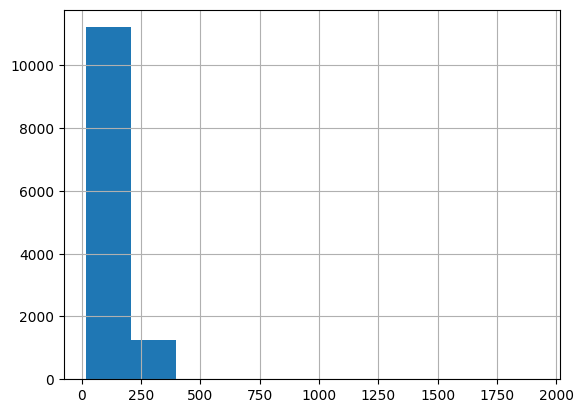

In [86]:
# 28

submission["CONSUMO_EP_VALOR"].hist()

In [87]:
# 29 el R2
from sklearn.metrics import r2_score

r2 = r2_score(y_val, y_pred)

print("R2:", r2)

R2: 0.0062010279698989645


# FIN